# Exploratory Data Analysis: IBM attrition

In [241]:
# Import pandas and plotly express
# prelude
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

kGold   = 1.618
kWidth  = 12
kHeight = kWidth/kGold
kWidthPx = 1024
kHeightPx = kWidthPx/kGold


In [242]:
# The dataset has 35 columns. Execute the cell below to avoid the columns to be truncated when displaying a table:
pd.options.display.max_columns = None

In [243]:
# Read the file IBM_HR_ATTRITION.csv:
df = pd.read_csv("../12_assets/02_EDA/IBM_HR_ATTRITION.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [244]:
# Use one line of code to display various statistics about the dataset:
df.describe(include="all")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,NaN,2,NaN,NaN,NaN,9,NaN,3,NaN,NaN,NaN,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,NaN,Male,NaN,NaN,NaN,Sales Executive,NaN,Married,NaN,NaN,NaN,Y,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,NaN,882,NaN,NaN,NaN,326,NaN,673,NaN,NaN,NaN,1470,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,2.721769,NaN,65.891156,2.729932,2.063946,NaN,2.728571,NaN,6502.931293,14313.103401,2.693197,NaN,NaN,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,1.093082,NaN,20.329428,0.711561,1.106940,NaN,1.102846,NaN,4707.956783,7117.786044,2.498009,NaN,NaN,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,1.000000,NaN,30.000000,1.000000,1.000000,NaN,1.000000,NaN,1009.000000,2094.000000,0.000000,NaN,NaN,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,2.000000,NaN,48.000000,2.000000,1.000000,NaN,2.000000,NaN,2911.000000,8047.000000,1.000000,NaN,NaN,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,3.000000,NaN,66.000000,3.000000,2.000000,NaN,3.000000,NaN,4919.000000,14235.500000,2.000000,NaN,NaN,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,4.000000,NaN,83.750000,3.000000,3.000000,NaN,4.000000,NaN,8379.000000,20461.500000,4.000000,NaN,NaN,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [245]:
# You can also use the .info() method to display some information about the data:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Who are IBM's employees?

In [246]:
# We'll first focus on very basic questions about age, gender, education level, etc...
# How are the ages distributed?

px.histogram(df, x=df["Age"], width=kWidthPx, height=kHeightPx)




In [247]:
px.box(df, x="Age", width=kWidthPx, height=kHeightPx)

In [282]:
# Is the distribution of ages different for men and women? Find two ways of investigating the difference
px.histogram(df, x="Age", color="Gender", width=kWidthPx, height=kHeightPx)


In [249]:
# What are the different education levels proportions?
100*df.groupby(["Education"])["Age"].count()/len(df) # j'utilise "Age" mais c'est juste pour avoir 1 seule colonne

Education
1    11.564626
2    19.183673
3    38.911565
4    27.074830
5     3.265306
Name: Age, dtype: float64

In [250]:
# Same question for the education field?
100*df.groupby(["EducationField"])["Age"].count()/len(df)

EducationField
Human Resources      1.836735
Life Sciences       41.224490
Marketing           10.816327
Medical             31.564626
Other                5.578231
Technical Degree     8.979592
Name: Age, dtype: float64

In [251]:
# What percentage of the employees never travel for business?

df["BusinessTravel"].value_counts() # popur retrouver Non-Travel

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

In [252]:
100*df.groupby(["BusinessTravel"])["Age"].count()/len(df)

BusinessTravel
Non-Travel           10.204082
Travel_Frequently    18.843537
Travel_Rarely        70.952381
Name: Age, dtype: float64

In [253]:
100*(df["BusinessTravel"]=="Non-Travel").value_counts()/len(df)

BusinessTravel
False    89.795918
True     10.204082
Name: count, dtype: float64

In [254]:
# What's the percentage of women?
100*(df["Gender"]=="Female").value_counts()/len(df)

Gender
False    60.0
True     40.0
Name: count, dtype: float64

## Monthly Income

In [255]:
# As regards the income, is there equality between men and women?
df.groupby(["Gender"])["MonthlyIncome"].mean()

Gender
Female    6686.566327
Male      6380.507937
Name: MonthlyIncome, dtype: float64

In [256]:
df.groupby(["Gender"])["MonthlyIncome"].describe(include='all')

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,588.0,6686.566327,4695.608507,1129.0,3037.0,5081.5,8711.75,19973.0
Male,882.0,6380.507937,4714.856577,1009.0,2819.5,4837.5,8113.75,19999.0


In [257]:
# Is the income correlated to the employee's age?
px.scatter(df, x="Age", y="MonthlyIncome", width=kWidthPx, height=kHeightPx)


### Le graphe ci-dessus n'est pas clair
* À refaire
* Faut tracer le income en fonction de l'age

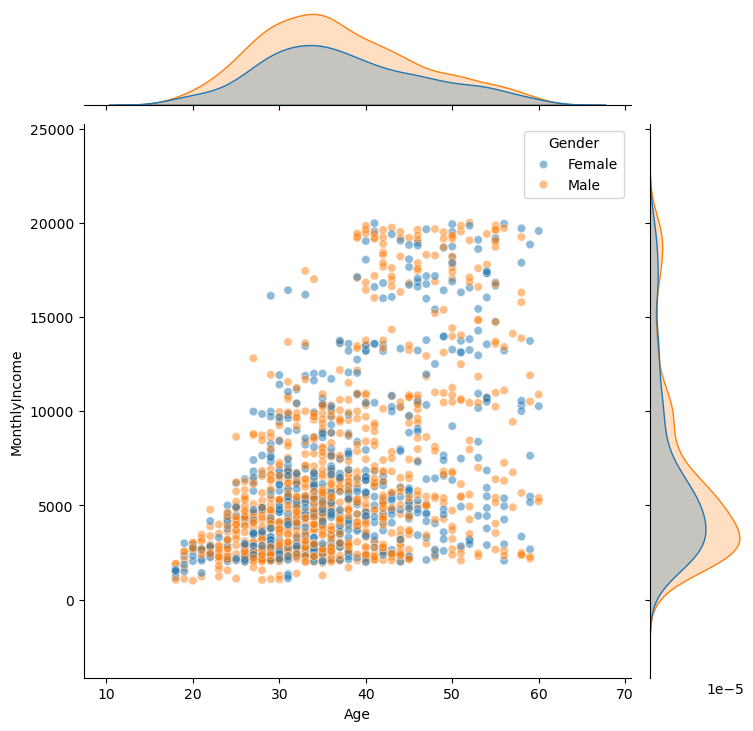

In [258]:
# fig, ax = plt.subplots(figsize=(kWidth,kHeight))
_ = sns.jointplot(df, x="Age", y="MonthlyIncome", alpha=.5, hue="Gender", height=kHeight)
# ax.set_title("Monthly income as a function of Age")
# ax.set_xlabel("Age (years)")
# _ = ax.set_ylabel("Monthly Income ($)")

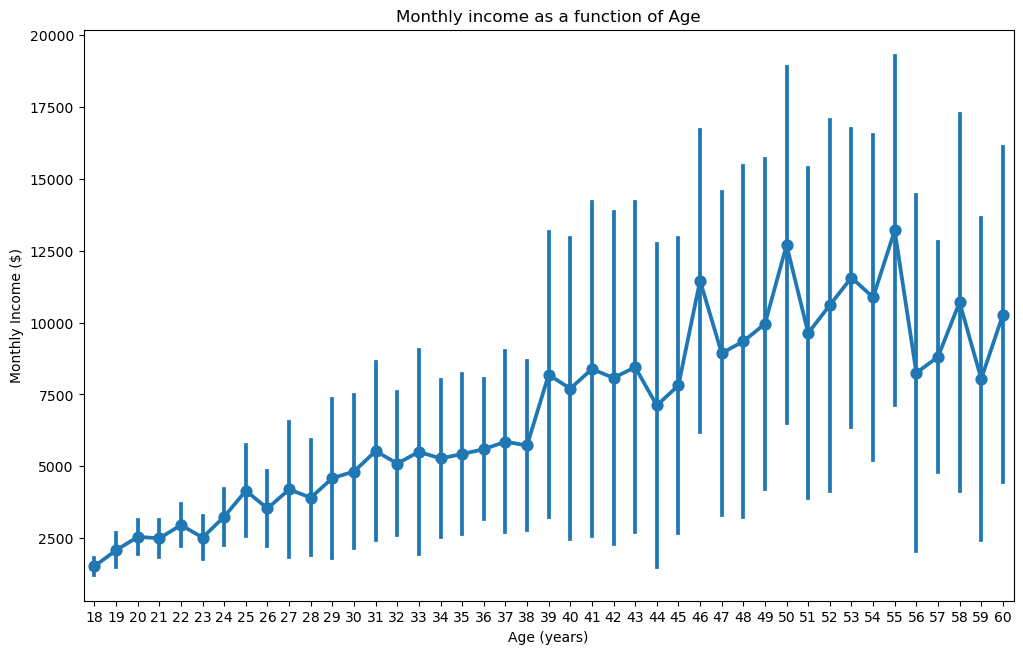

In [259]:
fig, ax = plt.subplots(figsize=(kWidth,kHeight))
sns.pointplot(df, x="Age", y="MonthlyIncome", errorbar='sd')

ax.set_title("Monthly income as a function of Age")
ax.set_xlabel("Age (years)")
_ = ax.set_ylabel("Monthly Income ($)")

### Note

* Faudrait voir l'ancienneté
  * TotalWorkingYears et YearsAtCompany
* A partir de 39 ans c'est quasiment pareil pour tout le monde. Bizarre

<Axes: xlabel='YearsAtCompany', ylabel='MonthlyIncome'>

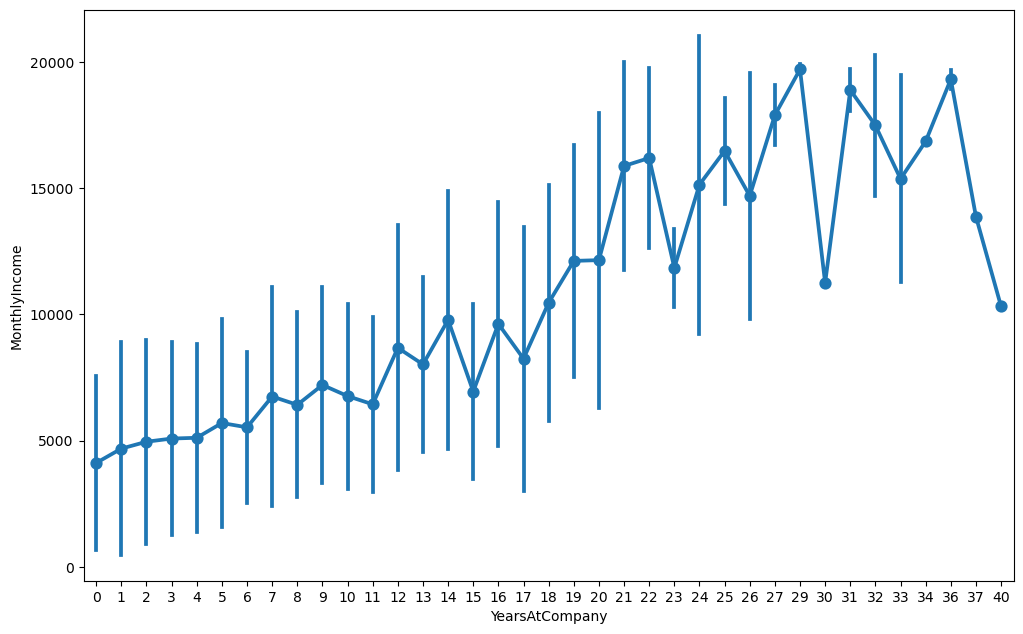

In [260]:
fig, ax = plt.subplots(figsize=(kWidth,kHeight))
sns.pointplot(df, x="YearsAtCompany", y="MonthlyIncome", errorbar='sd')

# ax.set_title("Monthly income as a function of Age")
# ax.set_xlabel("Age (years)")
# _ = ax.set_ylabel("Monthly Income ($)")

<Axes: xlabel='TotalWorkingYears', ylabel='MonthlyIncome'>

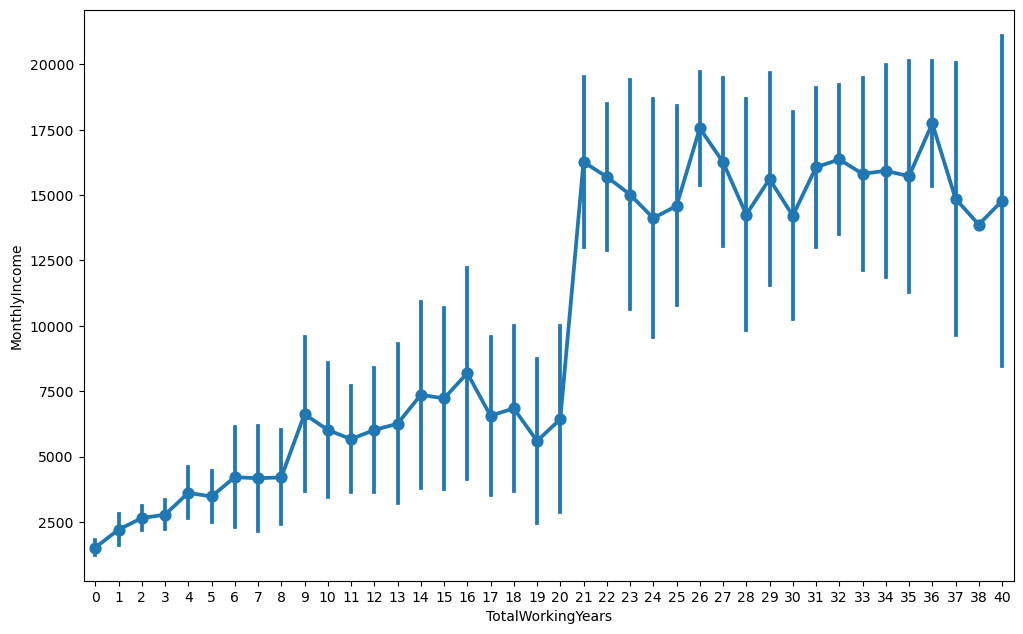

In [261]:
fig, ax = plt.subplots(figsize=(kWidth,kHeight))
sns.pointplot(df, x="TotalWorkingYears", y="MonthlyIncome", errorbar='sd')

# ax.set_title("Monthly income as a function of Age")
# ax.set_xlabel("Age (years)")
# _ = ax.set_ylabel("Monthly Income ($)")

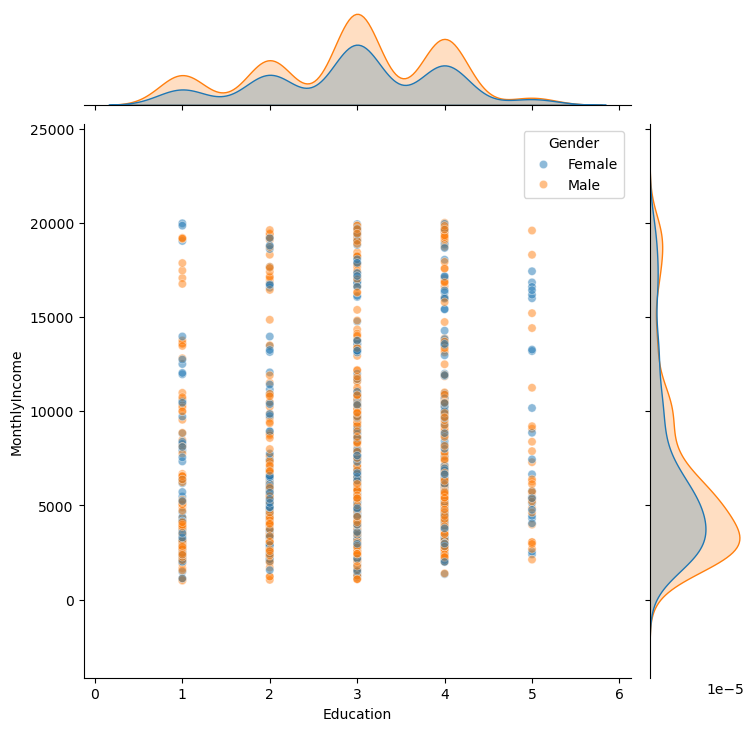

In [262]:
# Does the income depend on the education level?
# px.scatter(df, x="Education", y="MonthlyIncome", width=kWidthPx, height=kHeightPx)
_ = sns.jointplot(df, x="Education", y="MonthlyIncome", alpha=.5, hue="Gender", height=kHeight)


* Non
* On peut faire 20k/mois avec level 1 ou 5


In [263]:
# The income depends a bit on the education level, especially for highest level (5) who tend to earn more money than others.
# Does the monthly income depend on the employee's frequency of travel?

Text(0.5, 1.0, 'Income vs Business Travel')

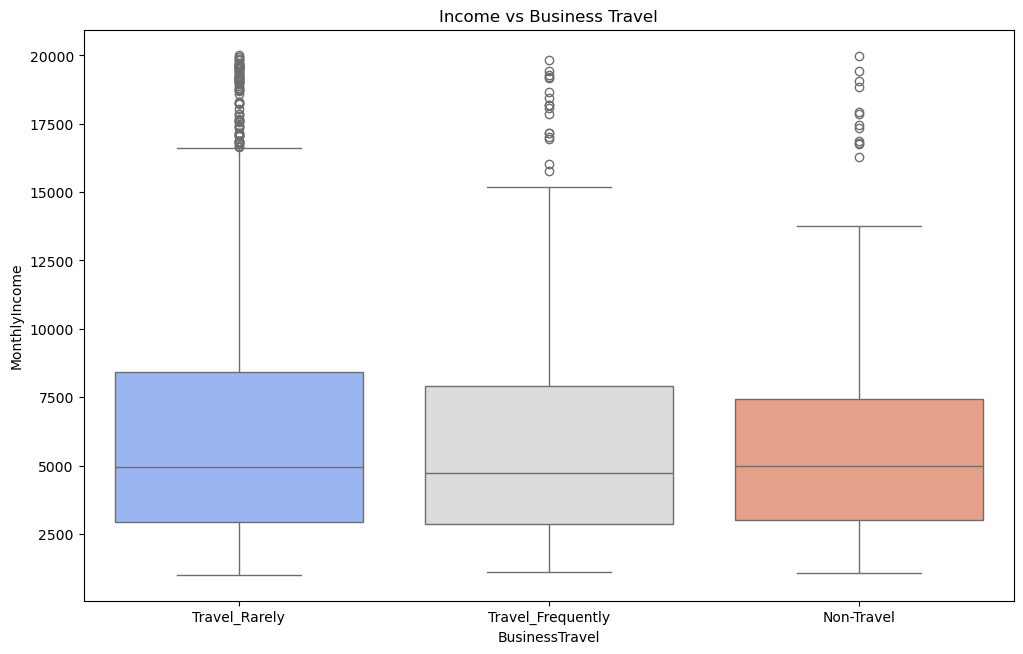

In [264]:
# px.scatter(df, x="BusinessTravel", y="MonthlyIncome", width=kWidthPx, height=kHeightPx)
# _ = sns.jointplot(df, x="BusinessTravel", y="MonthlyIncome", alpha=.5, hue="Gender", height=kHeight)

fig, ax = plt.subplots(figsize=(kWidth, kHeight))
sns.boxplot(df, x="BusinessTravel", y="MonthlyIncome", palette="coolwarm", hue="BusinessTravel", legend=False, ax=ax)
ax.set_title("Income vs Business Travel")
# ax.set_xlabel("Meal Time")
# ax.set_ylabel("Total Bill ($)")


Text(0.5, 1.0, 'Income vs Education')

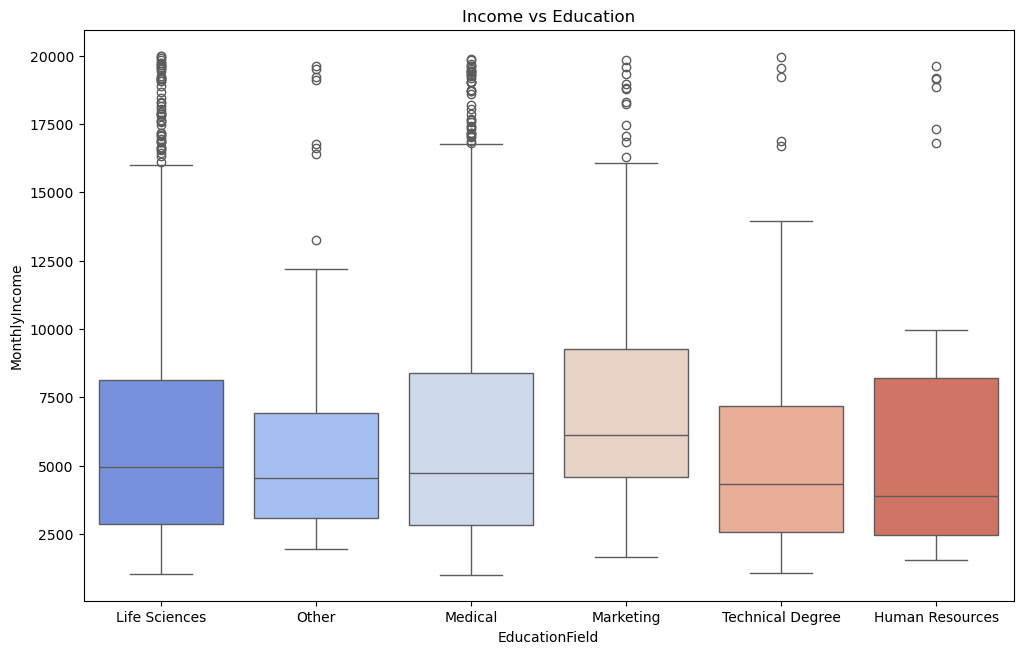

In [265]:
# What is the education field with the highest incomes in general?
# px.scatter(df, x="EducationField", y="MonthlyIncome", width=kWidthPx, height=kHeightPx)
fig, ax = plt.subplots(figsize=(kWidth,kHeight))
sns.boxplot(df, x="EducationField", y="MonthlyIncome", palette="coolwarm", hue="EducationField", legend=False, ax=ax)
ax.set_title("Income vs Education")
# ax.set_xlabel("Meal Time")
# ax.set_ylabel("Total Bill ($)")


## Attrition

In [266]:
# Let's investigate the employees' attritions.
# What percentage of the employees did quit their job?

100*df.groupby(["Attrition"])["Age"].count()/len(df)

Attrition
No     83.877551
Yes    16.122449
Name: Age, dtype: float64

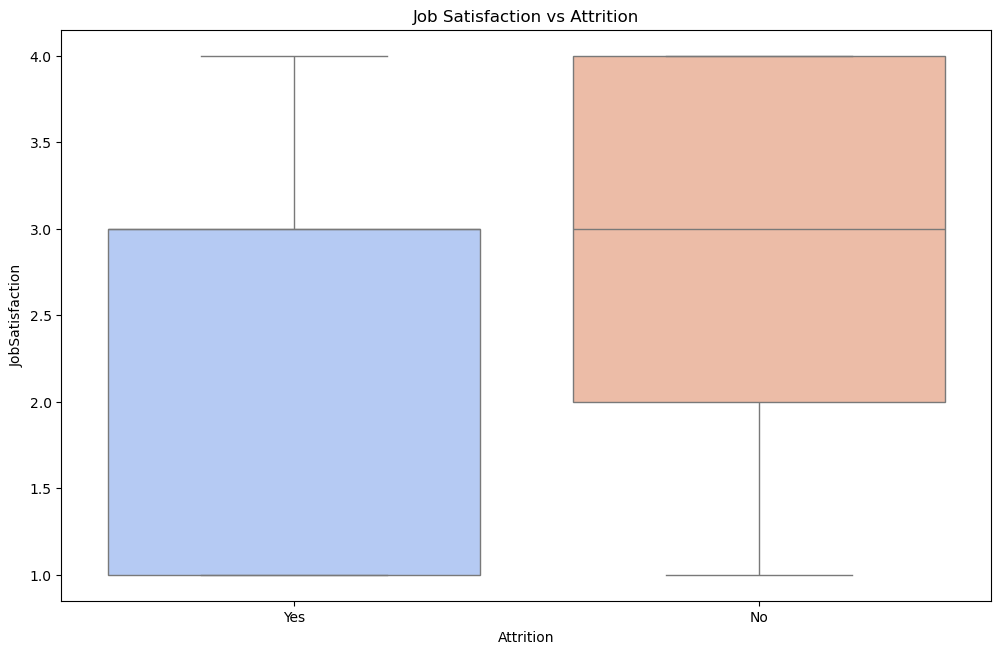

In [267]:
# Could we anticipate an employee's attrition from his level of satisfaction in his job?

fig, ax = plt.subplots(figsize=(kWidth, kHeight))
sns.boxplot(df, x="Attrition", y="JobSatisfaction", palette="coolwarm", hue="Attrition", legend=False, ax=ax)
_ = ax.set_title("Job Satisfaction vs Attrition")



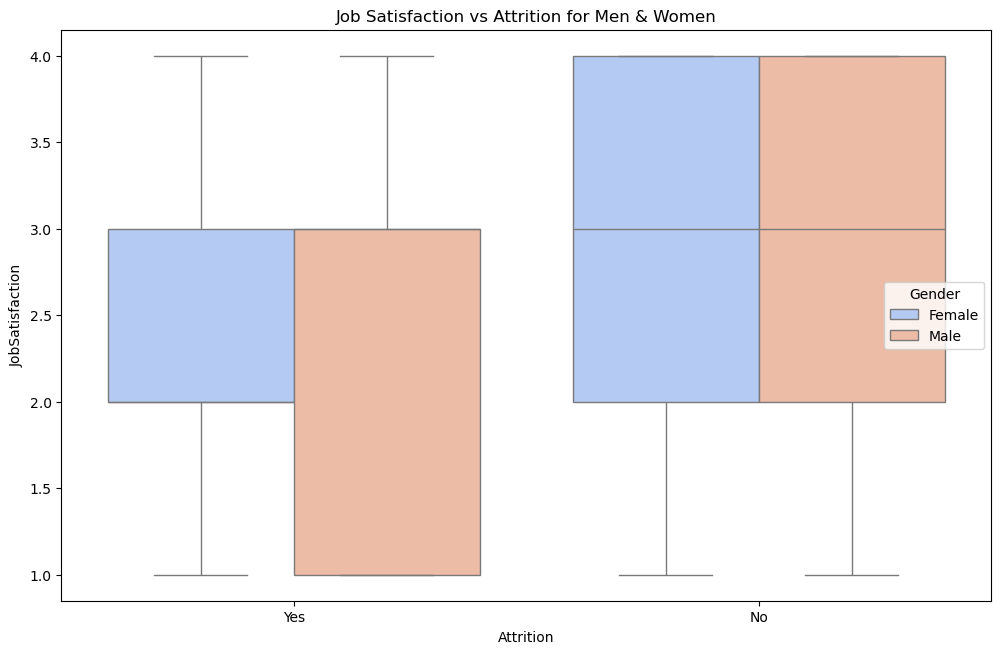

In [268]:
# Is this different between men and women?

fig, ax = plt.subplots(figsize=(kWidth, kHeight))
sns.boxplot(df, x="Attrition", y="JobSatisfaction", palette="coolwarm", hue="Gender",  ax=ax)
_ = ax.set_title("Job Satisfaction vs Attrition for Men & Women")


In [269]:
# Now we would like to investigate the relationship between attrition and education field. 
# We can't proceed like the previous analyses, as attrition and education field are both categorical variables! 

# Let's do something else:
#     Convert the Attrition column such that "Yes" is mapped to 1 and "No" is mapped to 0
#     Then, compute the average of Attrition grouped by the education field
#     Finally, plot the average attrition as a function of the education field.
#     What is the education field with the highest attrition rate?

df["Attrition"] = df["Attrition"].apply(lambda x : 0 if x =="No" else 1)


In [276]:
bob = 100*df.groupby(["EducationField"])["Attrition"].mean().sort_values()

In [279]:
fig = px.bar(bob, width=kWidthPx, height=kHeightPx)
fig.update_layout(showlegend=False)